# EDA PENGWIN — análisis exploratorio orientado a decisiones

**Proyecto Integrador Corte 2 · Analítica de Datos · UAO 2026-2**

> *El sistema desarrollado tiene exclusivamente fines académicos. No constituye un dispositivo médico, no ha sido validado clínicamente y no debe utilizarse para apoyar decisiones quirúrgicas reales.*

Este notebook no describe los datos por describirlos: cada sección responde una pregunta que **condiciona una decisión del proyecto** y termina con un recuadro **Decisión**. El resumen de todas las decisiones está en la sección 12.

| § | Pregunta | Decisión que condiciona |
|---|---|---|
| 1 | ¿Los archivos son íntegros y consistentes? | Reorientación, tipos de dato |
| 2 | ¿Qué geometría y resolución tienen los volúmenes? | Recorte, tamaño de entrada, 2.5D |
| 3 | ¿Dónde está el hueso en la escala HU? | Ventana, umbral del MIP |
| 4 | ¿Hay metal que afecte la pelvis? | Exclusión de casos, criterio de metal |
| 5 | ¿Cuántos fragmentos y con qué patrón? | Taxonomía, estratificación del split |
| 6 | ¿Cómo son los fragmentos (tamaño, forma, conectividad)? | Post-proceso de instancias, extensión de elongación |
| 7 | ¿A qué distancia están los fragmentos del principal? | Convención de la medida en mm, cabeza de borde |
| 8 | ¿Cómo se ve todo esto corte a corte (2D)? | Cabezas de clasificación, detección y segmentación |
| 9 | ¿La partición train/val/test está balanceada? | Mantener o regenerar `splits.json` |
| 10 | ¿Qué casos serán difíciles? | Lista de vigilancia para el análisis de errores |
| 11 | Inspección visual | Validación cualitativa de todo lo anterior |
| 12 | Resumen de decisiones | — |

**Cómo se regenera.** El cálculo pesado (leer 100 volúmenes, ~30 s por caso) está en `scripts/run_eda_extract.py`, que deja un JSON por caso en `reports/eda/cache/` (no versionado). Este notebook consolida esos JSON en `reports/eda/eda_*.csv` (versionados) y solo lee tablas, así que corre en segundos. Si no existe el caché, lee directamente los CSV.

**Convenciones.** Todos los volúmenes se reorientan a **LPS** (x → izquierda del paciente, y → posterior, z → superior). Las distancias están en **mm** (spacing del header). "Tamaño a 256" significa píxeles en la entrada del modelo tras recortar y redimensionar el corte a 256×256.

In [28]:
import os
import sys
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.precision", 3)


def find_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "03_src" / "pengwin").is_dir():
            return p
    raise FileNotFoundError("No se encontró la raíz del repositorio (carpeta 03_src/pengwin)")


ROOT = find_root()
sys.path.insert(0, str(ROOT / "03_src"))
from pengwin.eda.consolidate import export_tables, load_eda_tables  # noqa: E402

CACHE = ROOT / "reports" / "eda" / "cache"
TABLES = Path(os.environ.get("EDA_TABLES_DIR", ROOT / "reports" / "eda"))
FIG = ROOT / "reports" / "figures" / "eda"
FIG.mkdir(parents=True, exist_ok=True)

if "EDA_TABLES_DIR" not in os.environ and CACHE.is_dir() and any(CACHE.glob("*.json")):
    T = load_eda_tables(CACHE, ROOT / "01_data" / "splits.json")
    export_tables(T, TABLES)
    cases, frags, slices = T["cases"], T["fragments"], T["slices"]
    HU = {"bone": T["hist_bone"], "all": T["hist_all"], "edges": T["hist_edges"]}
    origen = f"caché JSON ({len(cases)} casos) -> tablas exportadas a {TABLES.relative_to(ROOT)}"
else:
    rd = dict(dtype={"case_id": str})
    cases = pd.read_csv(TABLES / "eda_cases.csv", **rd)
    frags = pd.read_csv(TABLES / "eda_fragments.csv", **rd)
    slices = pd.read_csv(TABLES / "eda_slices.csv.gz", **rd)
    HU = dict(np.load(TABLES / "eda_hu_hist.npz"))
    origen = f"CSV en {TABLES}"

REG = ["SA", "LI", "RI"]
REG_NAME = {"SA": "Sacro", "LI": "Coxal izquierdo", "RI": "Coxal derecho"}
print(f"Origen de datos: {origen}")
print(f"casos={len(cases)} | fragmentos={len(frags)} | cortes con hueso={len(slices)}")

Origen de datos: caché JSON (100 casos) -> tablas exportadas a reports\eda
casos=100 | fragmentos=575 | cortes con hueso=24316


In [29]:
# --- Estilo de figuras -------------------------------------------------------
# Color por ENTIDAD, fijo en todo el notebook: sacro, coxal izq., coxal der.
# (tres primeros tonos de una paleta categórica validada para daltonismo).
C = {"SA": "#2a78d6", "LI": "#eb6834", "RI": "#1baf7a"}
INK, INK2, MUTED, GRID, AXIS, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
MAIN_C, SEC_C = "#52514e", "#4a3aa7"       # fragmento principal (neutro) vs secundario
REF = "#d03b3b"                            # líneas de referencia / umbrales

mpl.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 8, "font.size": 9,
    "lines.linewidth": 2, "patch.linewidth": 0,
})


def savefig(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight")


def ecdf(ax, values, color, label=None, **kw):
    v = np.sort(np.asarray(values)[~np.isnan(values)])
    ax.step(v, np.arange(1, v.size + 1) / v.size, where="post", color=color, label=label, **kw)


def pct(x):
    return f"{100 * x:.1f} %"

## 1. Integridad y orientación

¿Se puede confiar en los archivos tal cual? Se revisa que imagen y etiqueta compartan geometría, el tipo de dato, la isotropía en el plano y la orientación anatómica original.

In [30]:
n = len(cases)
main_low = cases.filter(like="main_is_lowest").stack()
checks = pd.DataFrame([
    ("Casos con imagen y etiqueta", f"{n}"),
    ("Headers idénticos (tamaño, spacing, origen, dirección)", f"{int(cases.header_match.sum())}/{n}"),
    ("Tipo de dato de la imagen", ", ".join(f"{k} ({v})" for k, v in cases.pixel_type.value_counts().items())),
    ("Píxel cuadrado en el plano (dx == dy)", f"{int(np.isclose(cases.dx, cases.dy).sum())}/{n}"),
    ("Orientación original LPS / RAS", " / ".join(str(cases.orientation_orig.value_counts().get(k, 0)) for k in ["LPS", "RAS"])),
    ("Principal = etiqueta más baja = mayor volumen", f"{int(main_low.sum())}/{main_low.size} regiones"),
    ("Etiquetas fuera de 1-30", "0 (verificado en 02_auditoria)"),
], columns=["Verificación", "Resultado"])
checks

,Verificación,Resultado
0,Casos con imagen y etiqueta,100
1,"Headers idénticos (tamaño, spacing, origen, di...",100/100
2,Tipo de dato de la imagen,"32-bit signed integer (53), 16-bit signed inte..."
3,Píxel cuadrado en el plano (dx == dy),100/100
4,Orientación original LPS / RAS,66 / 34
5,Principal = etiqueta más baja = mayor volumen,300/300 regiones
6,Etiquetas fuera de 1-30,0 (verificado en 02_auditoria)


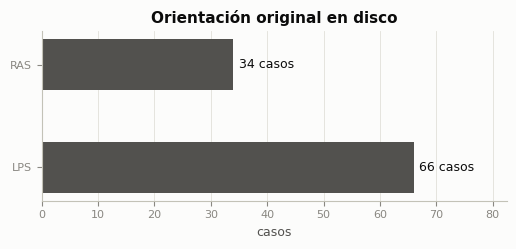

In [31]:
fig, ax = plt.subplots(figsize=(6, 2.2))
vc = cases.orientation_orig.value_counts().reindex(["LPS", "RAS"]).fillna(0)
ax.barh(vc.index, vc.values, color=INK2, height=0.5)
for y, v in enumerate(vc.values):
    ax.text(v + 1, y, f"{int(v)} casos", va="center", color=INK, fontsize=9)
ax.set_xlim(0, max(vc.values) * 1.25)
ax.set_title("Orientación original en disco")
ax.set_xlabel("casos")
ax.grid(axis="y", visible=False)
savefig(fig, "01_orientacion")

> **Decisión 1 — Integridad y orientación**
> - Los 100 pares imagen/etiqueta comparten geometría y el píxel es cuadrado en todos: **no hay que remuestrear la máscara** ni corregir aspecto en el plano.
> - La imagen viene como `int32` (53 casos) o `int16` (47): el loader la pasa a `float32`. Las etiquetas (0–30) se guardan en `uint8`.
> - **66 casos LPS y 34 RAS → reorientar a LPS es obligatorio** antes de extraer cortes. Sin eso, izquierda y derecha se invierten en un tercio del dataset. Lo verifica `06_tests/test_orientation.py`, que antes pasaba siempre porque solo comparaba `izq != der`.
> - El fragmento principal es la etiqueta más baja **y** el de mayor volumen en 300/300 regiones. En el GT se usa la regla 1/11/21; en la predicción, "principal" = componente 3D de mayor volumen de la región.

## 2. Geometría, resolución y recorte

El modelo recibe cortes de 256×256. La pregunta es **cuántos mm representa cada píxel** según cómo se recorte el corte antes de redimensionarlo:

- **Sin recorte**: el FOV completo del escáner.
- **Recorte al cuerpo**: cuadrado sobre la silueta del paciente (sin camilla), calculado solo con la imagen.
- **Recorte óseo**: cuadrado sobre las columnas con ≥ 10 mm de hueso (HU ≥ 250) dentro del cuerpo, también solo con la imagen, por lo que es válido en inferencia.

In [32]:
geo = cases[["dim_x", "dim_y", "dim_z", "dx", "dz", "fov_x_mm", "fov_y_mm", "slices_with_bone", "bone_z_extent_mm",
             "px_mm_no_crop_256", "px_mm_crop_256", "px_mm_bonecrop_256", "bone_bbox_w_mm", "bone_bbox_h_mm"]]
geo.describe().T[["min", "25%", "50%", "75%", "max"]]

,min,25%,50%,75%,max
dim_x,322.000,508.000,512.000,512.000,512.000
dim_y,154.000,299.500,512.000,512.000,512.000
dim_z,193.000,285.750,326.000,350.000,414.000
dx,0.658,0.781,0.798,0.858,1.220
dz,0.625,0.800,0.801,1.000,1.250
fov_x_mm,307.051,376.523,400.000,425.854,499.712
fov_y_mm,159.768,237.979,399.936,418.750,499.712
slices_with_bone,165.000,217.750,251.500,266.000,347.000
bone_z_extent_mm,183.000,205.000,213.307,220.850,258.000
px_mm_no_crop_256,1.199,1.471,1.562,1.663,1.952


Mediana mm/píxel a 256: {'sin recorte': np.float64(1.56), 'recorte al cuerpo': np.float64(1.54), 'recorte óseo': np.float64(1.27)}
Ganancia del recorte óseo frente a sin recorte: 19 % menos mm por píxel
El recorte óseo contiene todo el hueso etiquetado en 100/100 casos (margen mínimo 10.9 mm)
El recorte al cuerpo contiene todo el hueso etiquetado en 100/100 casos


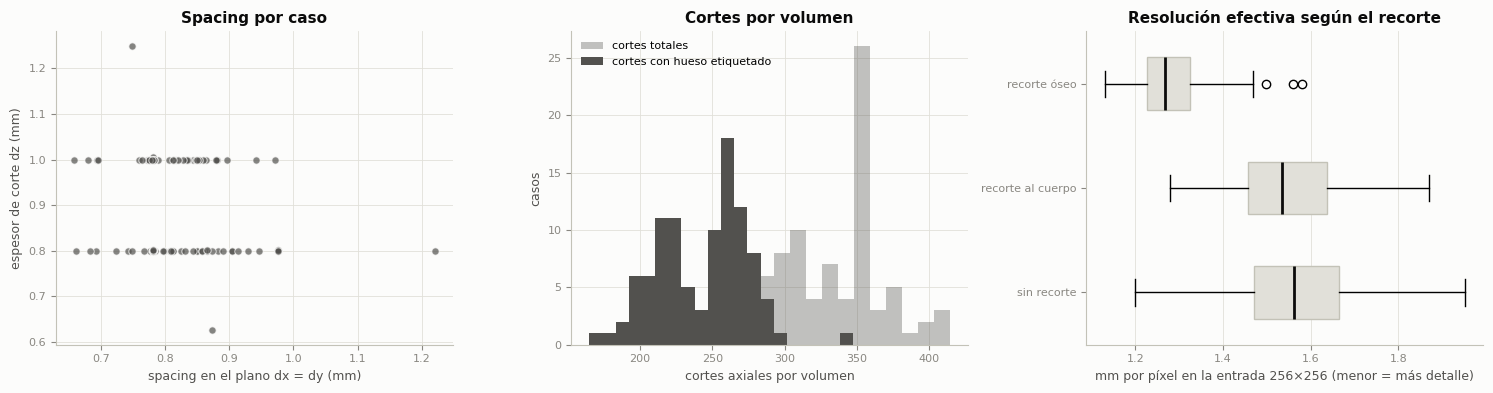

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.scatter(cases.dx, cases.dz, s=28, color=INK2, alpha=0.7, edgecolor=SURF, linewidth=0.8)
ax.set_xlabel("spacing en el plano dx = dy (mm)")
ax.set_ylabel("espesor de corte dz (mm)")
ax.set_title("Spacing por caso")

ax = axes[1]
ax.hist(cases.dim_z, bins=20, color=INK2, alpha=0.35, label="cortes totales")
ax.hist(cases.slices_with_bone, bins=20, color=INK2, label="cortes con hueso etiquetado")
ax.set_xlabel("cortes axiales por volumen")
ax.set_ylabel("casos")
ax.set_title("Cortes por volumen")
ax.legend()

ax = axes[2]
cols = {"sin recorte": "px_mm_no_crop_256", "recorte al cuerpo": "px_mm_crop_256", "recorte óseo": "px_mm_bonecrop_256"}
data = [cases[c].values for c in cols.values()]
bp = ax.boxplot(data, vert=False, widths=0.5, patch_artist=True, medianprops=dict(color=INK, linewidth=2))
for b in bp["boxes"]:
    b.set(facecolor=GRID, edgecolor=AXIS)
ax.set_yticks([1, 2, 3], list(cols))
ax.set_xlabel("mm por píxel en la entrada 256×256 (menor = más detalle)")
ax.set_title("Resolución efectiva según el recorte")
ax.grid(axis="y", visible=False)
fig.tight_layout()
savefig(fig, "02_geometria")

med = {k: cases[c].median() for k, c in cols.items()}
print("Mediana mm/píxel a 256:", {k: round(v, 2) for k, v in med.items()})
print(f"Ganancia del recorte óseo frente a sin recorte: {100 * (1 - med['recorte óseo'] / med['sin recorte']):.0f} % menos mm por píxel")
print(f"El recorte óseo contiene todo el hueso etiquetado en {int(cases.bone_inside_bonecrop.sum())}/{n} casos "
      f"(margen mínimo {cases.bonecrop_margin_min_mm.min():.1f} mm)")
print(f"El recorte al cuerpo contiene todo el hueso etiquetado en {int(cases.bone_inside_crop.sum())}/{n} casos")

In [34]:
# 2.5D: cuántos cortes de separación equivalen a ~2 mm físicos (canales z-Δ, z, z+Δ)
cases["delta_2mm"] = np.maximum(1, np.round(2.0 / cases.dz)).astype(int)
print("Δ (en cortes) para ~2 mm:", cases.delta_2mm.value_counts().sort_index().to_dict())
print("Espesor físico real de Δ (mm):", (cases.delta_2mm * cases.dz).describe()[["min", "50%", "max"]].round(2).to_dict())
print(f"Cortes con hueso en todo el dataset: {int(cases.slices_with_bone.sum())} de {int(cases.dim_z.sum())} "
      f"({pct(cases.slices_with_bone.sum() / cases.dim_z.sum())})")

Δ (en cortes) para ~2 mm: {2: 78, 3: 22}
Espesor físico real de Δ (mm): {'min': 1.6, '50%': 2.0, 'max': 2.5}
Cortes con hueso en todo el dataset: 24316 de 32106 (75.7 %)


> **Decisión 2 — Recorte, resolución y 2.5D**
> - El **recorte al cuerpo no sirve**: 1,54 mm/píxel frente a 1,56 sin recorte, porque el paciente llena el FOV.
> - El **recorte óseo** (`compute_bone_crop`, solo con la imagen) baja a **1,29 mm/píxel (−18 %)** y contiene todo el hueso etiquetado en 100/100 casos, con ≥ 10,9 mm de margen. **Se adopta**, calculado una vez por volumen y aplicado igual a todos sus cortes. Por caso se guardan el recorte y el spacing efectivo (`side_mm / 256`) para convertir a mm.
> - **2.5D con Δ = round(2 mm / dz)**: Δ = 2 cortes en 78 casos y 3 en 22 (1,6–2,5 mm físicos).
> - **Muestreo:** 24 316 de 32 106 cortes (75,7 %) tienen hueso. Se entrena con esos cortes más ~10–15 % de cortes vacíos cercanos al rango óseo, para que las cabezas vean negativos.

## 3. Intensidades (HU): ventana y umbral del MIP

Se comparan los HU de **todos** los vóxeles con los HU **dentro de las etiquetas óseas**. El sombreado es la ventana actual del loader (L = 400, W = 1800 → [-500, 1300] HU); la línea discontinua es el umbral del visualizador 1 (250 HU).

Hueso etiquetado por debajo de 250 HU (umbral MIP): 43.6 % (media por caso)
Hueso fuera de la ventana [-500, 1300]: por debajo 0.0 %, por encima 0.4 %
Casos con relleno < -1024 HU fuera del círculo de reconstrucción: 37 (mínimo -6211 HU)
Vóxeles >= 250 HU que NO son pelvis etiquetada (fémures, columna, calcificaciones): mediana 354 cm3 por caso vs 769 cm3 de pelvis


,percentil de HU del hueso (mediana entre casos),HU
0,p01,-4.5
1,p05,54.5
2,p25,171.0
3,p50,287.0
4,p75,494.5
5,p95,925.0
6,p99,1154.5


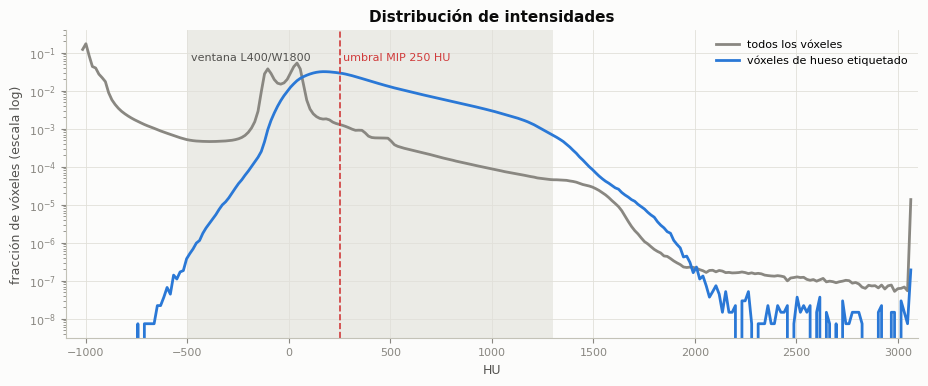

In [35]:
e = HU["edges"]
ctr = (e[:-1] + e[1:]) / 2
bone_d = HU["bone"] / HU["bone"].sum()
all_d = HU["all"] / HU["all"].sum()

fig, ax = plt.subplots(figsize=(11, 4))
ax.axvspan(-500, 1300, color=GRID, alpha=0.6, lw=0)
ax.text(-480, 0.9, "ventana L400/W1800", transform=ax.get_xaxis_transform(), color=INK2, fontsize=8)
ax.plot(ctr, all_d, color=MUTED, label="todos los vóxeles")
ax.plot(ctr, bone_d, color=C["SA"], label="vóxeles de hueso etiquetado")
ax.axvline(250, color=REF, ls="--", lw=1.2)
ax.text(265, 0.9, "umbral MIP 250 HU", transform=ax.get_xaxis_transform(), color=REF, fontsize=8)
ax.set_yscale("log")
ax.set_xlim(-1100, 3100)
ax.set_xlabel("HU")
ax.set_ylabel("fracción de vóxeles (escala log)")
ax.set_title("Distribución de intensidades")
ax.legend(loc="upper right")
savefig(fig, "03_hu")

bone_cdf = np.cumsum(bone_d)
def bone_frac_below(hu):
    return float(np.interp(hu, e[1:], bone_cdf))

tabla_hu = pd.DataFrame({
    "percentil de HU del hueso (mediana entre casos)": [f"p{p:02d}" for p in [1, 5, 25, 50, 75, 95, 99]],
    "HU": [cases[f"bone_hu_p{p:02d}"].median() for p in [1, 5, 25, 50, 75, 95, 99]],
})
print(f"Hueso etiquetado por debajo de 250 HU (umbral MIP): {pct(cases.bone_frac_below_mip_thr.mean())} (media por caso)")
print(f"Hueso fuera de la ventana [-500, 1300]: por debajo {pct(cases.bone_frac_below_window.mean())}, "
      f"por encima {pct(cases.bone_frac_above_window.mean())}")
print(f"Casos con relleno < -1024 HU fuera del círculo de reconstrucción: {int((cases.frac_below_air > 0).sum())} "
      f"(mínimo {cases.hu_min.min():.0f} HU)")
print(f"Vóxeles >= 250 HU que NO son pelvis etiquetada (fémures, columna, calcificaciones): mediana "
      f"{cases.above_mip_thr_outside_labels_cm3.median():.0f} cm3 por caso vs {cases.bone_volume_cm3.median():.0f} cm3 de pelvis")
tabla_hu

> **Decisión 3 — Ventana y umbrales**
> - El hueso etiquetado va de ≈ −5 HU (p1) a ≈ 1155 HU (p99). La ventana **L400/W1800 ([−500, 1300]) deja sin saturar el 99,6 % del hueso → se mantiene.**
> - **El 43,6 % del hueso etiquetado está por debajo de 250 HU** (hueso esponjoso).
>   - Para el MIP (visualizador 1) el umbral de 250 HU es correcto: lo que se ve es la cortical.
>   - Como segmentación sería desastroso: perdería casi la mitad del hueso. Es un argumento cuantitativo para el informe de por qué hace falta un modelo aprendido y no un umbral.
> - Hay 37 casos con relleno por debajo de −1024 HU (mínimo −6211). Se **recorta a −1024** antes de cualquier estadística o caché; la ventana ya lo hace para la entrada del modelo.
> - Por caso hay ~354 cm³ de tejido ≥ 250 HU que no es pelvis (fémures, columna) frente a ~769 cm³ de pelvis. El modelo debe aprender a excluir la cabeza femoral dentro del acetábulo: es un candidato a falsos positivos en el análisis de errores.

## 4. Metal y artefactos

La auditoría previa marcaba como "atípico" todo caso con HU máximo > 2500. Aquí se mide el **volumen** de vóxeles > 3000 HU, cuánto de ese volumen cae **dentro del hueso etiquetado** y a qué distancia del hueso está.

Criterio anterior (HU máx > 2500): 47 casos 'atípicos'
Casos con algún vóxel > 3000 HU: 41 | mediana del volumen: 0.176 cm3
Casos con > 0,5 cm3 de metal DENTRO del hueso (implante en pelvis): 0
Distancia mediana del metal al hueso: 49 mm


,case_id,hu_max,metal_cm3,metal_in_bone_cm3,metal_to_bone_mm
26,027,10827.0,21.810,0.0,8.905
99,100,24970.0,8.678,0.0,16.148
6,007,19380.0,5.279,0.0,29.725
67,068,30445.0,3.630,0.0,42.455
24,025,12939.0,2.946,0.0,31.073
56,057,16749.0,2.039,0.0,49.474
2,003,16709.0,1.929,0.0,47.166
73,074,15467.0,1.308,0.0,98.242


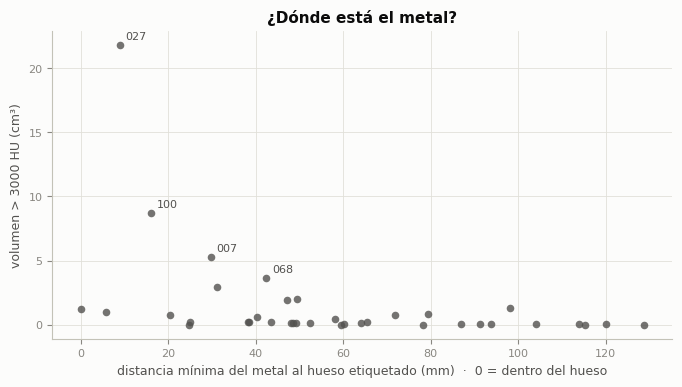

In [36]:
aud_path = ROOT / "02_auditoria" / "auditoria_calidad_casos.csv"
old_flag = None
if aud_path.exists():
    aud = pd.read_csv(aud_path, dtype={"case_id": str})
    aud["case_id"] = aud.case_id.str.zfill(3)
    old_flag = int((aud.hu_max > 2500).sum())

cases["metal_relevante"] = cases.metal_in_bone_cm3 > 0.5
fig, ax = plt.subplots(figsize=(8, 4))
m = cases.metal_cm3 > 0
ax.scatter(cases.loc[m, "metal_to_bone_mm"], cases.loc[m, "metal_cm3"], s=30, color=INK2, alpha=0.8, edgecolor=SURF)
for _, r in cases[m].nlargest(4, "metal_cm3").iterrows():
    ax.annotate(r.case_id, (r.metal_to_bone_mm, r.metal_cm3), xytext=(4, 4), textcoords="offset points", fontsize=8, color=INK2)
ax.set_xlabel("distancia mínima del metal al hueso etiquetado (mm)  ·  0 = dentro del hueso")
ax.set_ylabel("volumen > 3000 HU (cm³)")
ax.set_title("¿Dónde está el metal?")
savefig(fig, "04_metal")

print(f"Criterio anterior (HU máx > 2500): {old_flag} casos 'atípicos'")
print(f"Casos con algún vóxel > 3000 HU: {int(m.sum())} | mediana del volumen: {cases.loc[m, 'metal_cm3'].median():.3f} cm3")
print(f"Casos con > 0,5 cm3 de metal DENTRO del hueso (implante en pelvis): {int(cases.metal_relevante.sum())}")
print(f"Distancia mediana del metal al hueso: {cases.loc[m, 'metal_to_bone_mm'].median():.0f} mm")
cases.loc[m, ["case_id", "hu_max", "metal_cm3", "metal_in_bone_cm3", "metal_to_bone_mm"]].sort_values("metal_cm3", ascending=False).head(8)

> **Decisión 4 — Metal**
> - El criterio anterior (HU máx > 2500) marcaba 47 casos como "atípicos". Con el criterio volumétrico:
>   - **0 casos** tienen > 0,5 cm³ de metal dentro de la pelvis;
>   - el metal es poco (mediana 0,18 cm³) y está lejos del hueso (mediana 49 mm): cables, electrodos, botones.
> - **No se excluye ningún caso.** La auditoría pasa a usar `metal_in_bone_cm3` y `metal_to_bone_mm`.
> - Vigilar los casos **027** (21,8 cm³ a 8,9 mm del hueso) y **100** (8,7 cm³ a 16 mm): posible implante cerca de la cadera, con artefactos en estría sobre el acetábulo.
> - En la caché se recorta a 3071 HU para poder usar `int16` sin desbordar.

## 5. Fragmentos por caso y patrones de fractura

Una región con 1 fragmento = hueso sano; con > 1 = fracturado. Se revisa cuántos fragmentos hay por región y qué combinaciones de regiones fracturadas aparecen.

Patrones de regiones fracturadas (casos):
Coxal izquierdo                            19
Coxal izquierdo + Coxal derecho            18
Coxal derecho                              17
Sacro + Coxal izquierdo + Coxal derecho    16
Sacro + Coxal derecho                      13
Sacro + Coxal izquierdo                    13
Sacro                                       3
ninguna                                     1

Fragmentos totales por caso: mediana 6, rango 3-9
Máximo de fragmentos en una región: 6 (el formato admite 10)


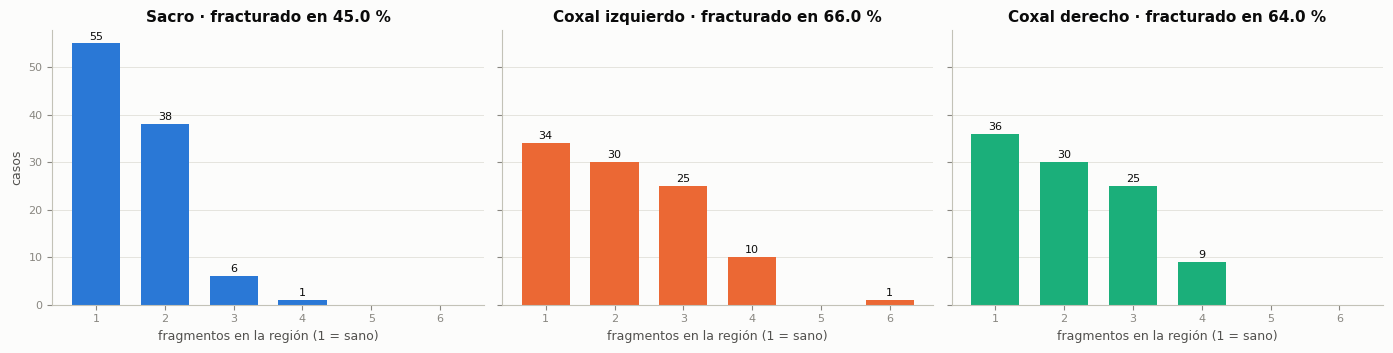

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
kmax = int(cases[[f"n_frag_{r}" for r in REG]].max().max())
for ax, r in zip(axes, REG):
    vc = cases[f"n_frag_{r}"].value_counts().reindex(range(1, kmax + 1), fill_value=0)
    ax.bar(vc.index, vc.values, color=C[r], width=0.7)
    for x, v in vc.items():
        if v:
            ax.text(x, v + 0.8, str(v), ha="center", fontsize=8, color=INK)
    ax.set_title(f"{REG_NAME[r]} · fracturado en {pct((cases[f'n_frag_{r}'] > 1).mean())}")
    ax.set_xlabel("fragmentos en la región (1 = sano)")
    ax.set_xticks(range(1, kmax + 1))
    ax.grid(axis="x", visible=False)
axes[0].set_ylabel("casos")
fig.tight_layout()
savefig(fig, "05_fragmentos_region")

patt = cases.apply(lambda r: " + ".join(REG_NAME[x] for x in REG if r[f"n_frag_{x}"] > 1) or "ninguna", axis=1)
cases["patron"] = patt
cases["total_fragments"] = cases[[f"n_frag_{r}" for r in REG]].sum(axis=1)
print("Patrones de regiones fracturadas (casos):")
print(patt.value_counts().to_string())
print(f"\nFragmentos totales por caso: mediana {cases.total_fragments.median():.0f}, rango {cases.total_fragments.min()}-{cases.total_fragments.max()}")
print(f"Máximo de fragmentos en una región: {kmax} (el formato admite 10)")

> **Decisión 5 — Taxonomía y patrones**
> - Las 3 regiones están presentes en los 100 casos.
> - Hay fracturas del sacro en 45 %, del coxal izquierdo en 66 % y del derecho en 64 %. Aparecen los 8 patrones posibles y solo 1 caso no tiene fractura.
> - El máximo es 6 fragmentos por región (el formato admite 10) y 3–9 por caso (mediana 6). No hacen falta "slots" fijos por fragmento.
> - La partición debe balancear el **patrón** de fractura por región, no solo el total de fragmentos (ver §9).

## 6. Fragmentos: tamaño, forma y conectividad 3D

Tres preguntas: ¿qué tan pequeños son los fragmentos secundarios (riesgo para Dice ≥ 0,85)? ¿Qué forma tienen (base de la extensión de elongación)? ¿Cada fragmento del GT es **una sola** componente conexa 3D (supuesto del post-proceso de instancias)?

Fragmentos: 575 (300 principales, 275 secundarios)
Volumen de secundarios (cm3): {'min': 0.28, '25%': 10.74, '50%': 22.18, '75%': 38.44, 'max': 108.67}
  secundarios < 1 cm3: 8 (2.9 %)
  secundarios < 5 cm3: 40 (14.5 %)
  secundarios < 10 cm3: 63 (22.9 %)
Elongación mediana: principal 1.52 | secundario 1.75


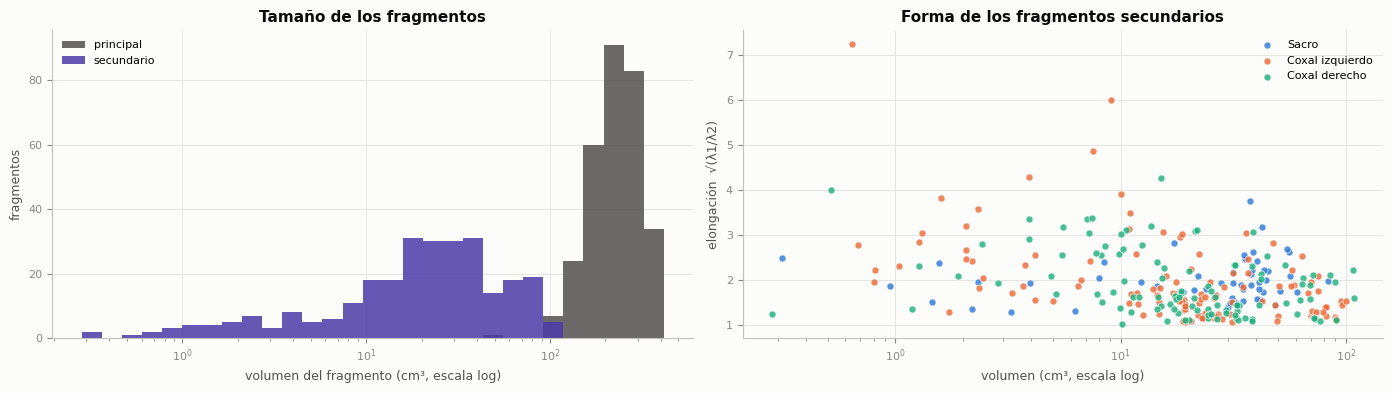

In [38]:
frags["tipo"] = np.where(frags.is_main, "principal", "secundario")
sec = frags[~frags.is_main].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
bins = np.logspace(np.log10(max(frags.volume_cm3.min(), 0.05)), np.log10(frags.volume_cm3.max()), 30)
ax.hist(frags.loc[frags.is_main, "volume_cm3"], bins=bins, color=MAIN_C, alpha=0.85, label="principal")
ax.hist(sec.volume_cm3, bins=bins, color=SEC_C, alpha=0.85, label="secundario")
ax.set_xscale("log")
ax.set_xlabel("volumen del fragmento (cm³, escala log)")
ax.set_ylabel("fragmentos")
ax.set_title("Tamaño de los fragmentos")
ax.legend()

ax = axes[1]
for r in REG:
    s_ = sec[sec.region == r]
    ax.scatter(s_.volume_cm3, s_.elongation, s=26, color=C[r], alpha=0.8, edgecolor=SURF, linewidth=0.6, label=REG_NAME[r])
ax.set_xscale("log")
ax.set_xlabel("volumen (cm³, escala log)")
ax.set_ylabel("elongación  √(λ1/λ2)")
ax.set_title("Forma de los fragmentos secundarios")
ax.legend()
fig.tight_layout()
savefig(fig, "06_fragmentos_tamano_forma")

print(f"Fragmentos: {len(frags)} ({int(frags.is_main.sum())} principales, {len(sec)} secundarios)")
print("Volumen de secundarios (cm3):", sec.volume_cm3.describe()[["min", "25%", "50%", "75%", "max"]].round(2).to_dict())
for thr in (1, 5, 10):
    print(f"  secundarios < {thr} cm3: {int((sec.volume_cm3 < thr).sum())} ({pct((sec.volume_cm3 < thr).mean())})")
print("Elongación mediana: principal {:.2f} | secundario {:.2f}".format(
    frags.loc[frags.is_main, "elongation"].median(), sec.elongation.median()))

In [39]:
conn = frags.groupby("tipo").agg(
    fragmentos=("label", "size"),
    con_mas_de_1_componente=("n_cc_3d", lambda s: int((s > 1).sum())),
    con_mas_de_1_componente_no_trivial=("n_cc_ge_100mm3", lambda s: int((s > 1).sum())),
    frac_vol_en_componente_mayor_min=("cc_largest_frac", "min"),
    frac_vol_en_componente_mayor_mediana=("cc_largest_frac", "median"),
)
print("Componentes conexas 3D (26-vecindad) de cada fragmento del GT")
print("'no trivial' = componente >= 0,1 cm3")
conn

Componentes conexas 3D (26-vecindad) de cada fragmento del GT
'no trivial' = componente >= 0,1 cm3


,fragmentos,con_mas_de_1_componente,con_mas_de_1_componente_no_trivial,frac_vol_en_componente_mayor_min,frac_vol_en_componente_mayor_mediana
tipo,,,,,
principal,300,33,6,0.996,1.0
secundario,275,75,27,0.721,1.0


In [40]:
multi = frags[frags.n_cc_ge_100mm3 > 1].sort_values("cc_largest_frac")
print(f"Fragmentos partidos en >1 pieza no trivial: {len(multi)} en {multi.case_id.nunique()} casos")
multi[["case_id", "region", "label", "tipo", "volume_cm3", "n_cc_3d", "n_cc_ge_100mm3", "cc_largest_frac"]].head(12)

Fragmentos partidos en >1 pieza no trivial: 33 en 28 casos


,case_id,region,label,tipo,volume_cm3,n_cc_3d,n_cc_ge_100mm3,cc_largest_frac
122,023,LI,12,secundario,0.807,2,2,0.721
365,064,SA,2,secundario,8.022,5,4,0.754
361,063,SA,3,secundario,3.966,5,3,0.766
232,041,SA,2,secundario,6.268,4,3,0.859
253,045,SA,2,secundario,2.334,5,2,0.869
451,079,LI,13,secundario,5.021,2,2,0.935
474,084,SA,2,secundario,38.651,5,5,0.939
220,039,LI,12,secundario,96.546,2,2,0.960
426,075,SA,2,secundario,41.329,3,3,0.970
558,098,SA,2,secundario,30.590,2,2,0.977


> **Decisión 6 — Fragmentos**
> - Los secundarios tienen una mediana de 22 cm³, pero **14,5 % mide < 5 cm³ y 2,9 % < 1 cm³**.
>   - Con 1,29 mm/píxel, 1 cm³ equivale a una esfera de ~9 píxeles de diámetro. Esos fragmentos arrastran el Dice medio.
>   - El Dice por fragmento se reporta **estratificado por volumen** (< 5, 5–20, > 20 cm³) y ponderado por volumen, además del promedio simple.
> - **Elongación:** mediana 1,75 en secundarios y 1,52 en principales. Los más alargados (> 3) suelen ser pequeños, lo que respalda la hipótesis de la extensión: "delgado y alargado → peor Dice", a verificar en la galería de peores casos.
> - **Conectividad del GT:**
>   - 75 secundarios y 33 principales tienen más de una componente 3D, pero solo **27 y 6** tienen más de una pieza ≥ 0,1 cm³ (la mayor conserva ≥ 72 % del volumen).
>   - El post-proceso por componentes 3D debe **reasignar las componentes < 0,1 cm³** a la instancia vecina.
>   - Hay que asumir que ~5 % de los fragmentos del GT está genuinamente partido: el emparejamiento pred↔GT se hace por IoU dentro de la región, sin suponer una sola pieza.

## 7. Distancia de separación y contacto

La medida obligatoria es la distancia mínima borde a borde (mm) de cada fragmento secundario al principal de su hueso, con `distance_transform_edt(~principal, sampling=(dz, dy, dx))`. La EDT mide de **centro a centro de vóxel**: dos fragmentos que se tocan dan ≈ 1 vóxel, no 0. Se usa como umbral de "contacto" la diagonal del vóxel.

Secundarios en contacto con el principal (d <= diagonal del vóxel): 244/275 (88.7 %)
Secundarios que tocan ALGÚN otro fragmento del mismo hueso: 93.5 %
Distancia de los que NO están en contacto (mm): {'count': 31.0, 'min': 1.6, '50%': 6.6, 'max': 73.1}
Superficie en contacto (mediana): 5.5 % de la superficie del fragmento


,case_id,region,label,volume_cm3,dist_to_main_mm
550,096,RI,23,10.283,73.118
484,085,LI,12,14.793,50.821
312,054,RI,24,1.191,40.369
223,039,RI,23,1.900,35.123
27,005,RI,23,7.082,24.292
129,024,LI,13,1.307,20.067
565,099,LI,12,12.518,14.227
311,054,RI,23,7.236,13.596
478,084,LI,14,0.813,12.930
205,037,SA,2,0.947,11.515


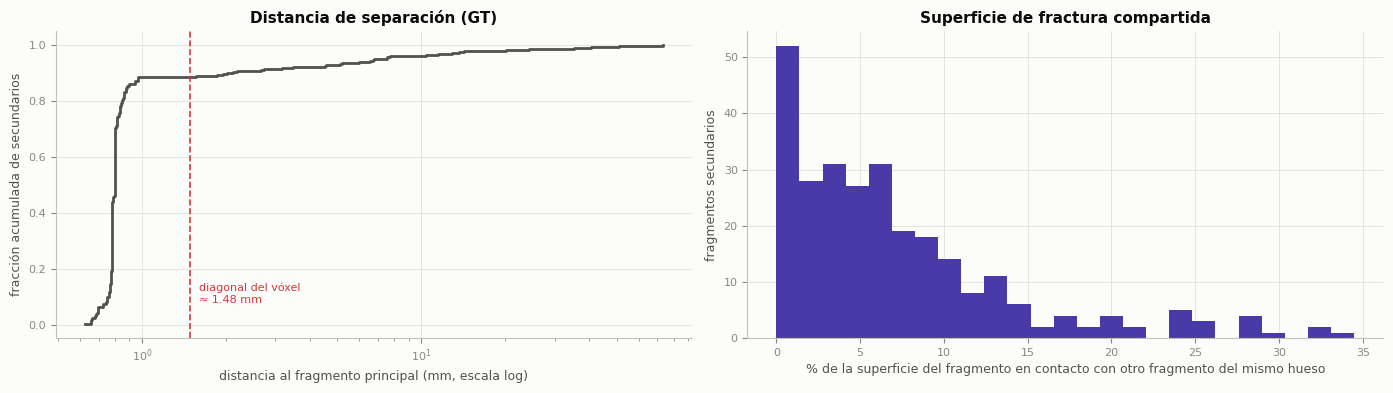

In [41]:
sec["contacto"] = sec.contact_with_main.astype(bool)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
ecdf(ax, sec.dist_to_main_mm.values, INK2)
diag = np.sqrt(2 * cases.dx**2 + cases.dz**2)
ax.axvline(diag.median(), color=REF, ls="--", lw=1.2)
ax.text(diag.median() * 1.08, 0.08, f"diagonal del vóxel\n≈ {diag.median():.2f} mm", color=REF, fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("distancia al fragmento principal (mm, escala log)")
ax.set_ylabel("fracción acumulada de secundarios")
ax.set_title("Distancia de separación (GT)")

ax = axes[1]
ax.hist(sec.contact_frac_surface * 100, bins=25, color=SEC_C)
ax.set_xlabel("% de la superficie del fragmento en contacto con otro fragmento del mismo hueso")
ax.set_ylabel("fragmentos secundarios")
ax.set_title("Superficie de fractura compartida")
fig.tight_layout()
savefig(fig, "07_separacion")

print(f"Secundarios en contacto con el principal (d <= diagonal del vóxel): {int(sec.contacto.sum())}/{len(sec)} ({pct(sec.contacto.mean())})")
print(f"Secundarios que tocan ALGÚN otro fragmento del mismo hueso: {pct(sec.touches_other_fragment.mean())}")
print("Distancia de los que NO están en contacto (mm):", sec.loc[~sec.contacto, "dist_to_main_mm"].describe()[["count", "min", "50%", "max"]].round(1).to_dict())
print(f"Superficie en contacto (mediana): {pct(sec.contact_frac_surface.median())} de la superficie del fragmento")
sec.loc[~sec.contacto, ["case_id", "region", "label", "volume_cm3", "dist_to_main_mm"]].sort_values("dist_to_main_mm", ascending=False).head(10)

               min  50%   max
dist_SA_LI_mm  1.2  1.6   3.1
dist_SA_RI_mm  1.3  1.6   3.1
dist_LI_RI_mm  1.4  3.4  34.8
Casos con sínfisis > 10 mm: [['015', 14.7], ['019', 27.9], ['022', 20.6], ['047', 22.4], ['063', 27.4], ['068', 13.0], ['072', 34.8], ['075', 15.4], ['088', 23.2], ['092', 30.0]]


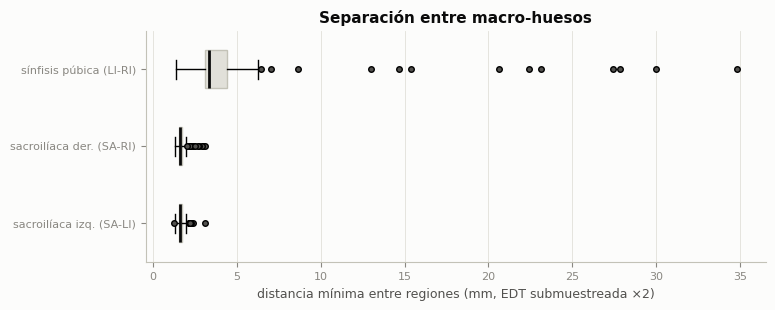

In [42]:
pairs = {"SA-LI": "dist_SA_LI_mm", "SA-RI": "dist_SA_RI_mm", "LI-RI": "dist_LI_RI_mm"}
fig, ax = plt.subplots(figsize=(8, 3))
bp = ax.boxplot([cases[c].dropna() for c in pairs.values()], vert=False, widths=0.5, patch_artist=True,
                medianprops=dict(color=INK, linewidth=2), flierprops=dict(marker="o", markersize=4, markerfacecolor=INK2))
for b in bp["boxes"]:
    b.set(facecolor=GRID, edgecolor=AXIS)
ax.set_yticks([1, 2, 3], ["sacroilíaca izq. (SA-LI)", "sacroilíaca der. (SA-RI)", "sínfisis púbica (LI-RI)"])
ax.set_xlabel("distancia mínima entre regiones (mm, EDT submuestreada ×2)")
ax.set_title("Separación entre macro-huesos")
ax.grid(axis="y", visible=False)
savefig(fig, "07_articulaciones")
print(cases[list(pairs.values())].describe().T[["min", "50%", "max"]].round(1))
print("Casos con sínfisis > 10 mm:", cases.loc[cases.dist_LI_RI_mm > 10, ["case_id", "dist_LI_RI_mm"]].round(1).values.tolist())

> **Decisión 7 — Distancia y contacto**
> - **88,7 % de los secundarios (244/275) toca al principal** y 93,5 % toca algún fragmento. La superficie compartida es pequeña: mediana 5,5 % de la superficie del fragmento.
> - Los 31 que no están en contacto están a 1,6–73 mm (mediana 6,6 mm).
> - Consecuencias:
>   1. La medida se reporta como la EDT mínima, pero **si d ≤ diagonal del vóxel (~1,5 mm) el dashboard muestra "en contacto"** en lugar de "0,8 mm".
>   2. El error de propagación (pred vs GT) se analiza **por separado** para fragmentos en contacto y separados.
>   3. Se necesita la salida de **borde de fractura** para no fusionar fragmentos que se tocan.
> - **Entre regiones:** las articulaciones sacroilíacas están a 1,2–3,1 mm, así que la frontera semántica SA↔coxal es de 1–2 píxeles. En la sínfisis hay 10 casos con > 10 mm (diastasis de hasta 35 mm), buenos para la demo.

## 8. Análisis corte a corte (lo que verá el modelo 2D)

Las tablas por corte se calcularon con el **recorte al cuerpo**; aquí se reescalan al **recorte óseo** (decisión de la §2) multiplicando por `crop_side_px / bonecrop_side_px` de cada caso.

In [43]:
scale = cases.set_index("case_id").eval("crop_side_px / bonecrop_side_px")
k = slices.case_id.map(scale)
for r in REG:
    for c in (f"{r}_w_256", f"{r}_h_256"):
        slices[c + "b"] = slices[c] * k
    for c in (f"{r}_area_256", f"{r}_min_frag_area_256"):
        slices[c + "b"] = slices[c] * k**2
slices["fg_px_256b"] = slices.fg_px_256 * k**2
slices["frac_edge_px_256b"] = slices.frac_edge_px_256 * k**2
for r in REG:
    slices[f"has_{r}"] = slices[f"has_{r}"].astype(bool)

total_slices = int(cases.dim_z.sum())
bone_slices = len(slices)
prev = pd.DataFrame({
    "% de cortes con hueso": [pct(slices[f"has_{r}"].mean()) for r in REG],
    "% de todos los cortes": [pct(slices[f"has_{r}"].sum() / total_slices) for r in REG],
    "pos_weight BCE (neg/pos, cortes con hueso)": [round((~slices[f"has_{r}"]).sum() / slices[f"has_{r}"].sum(), 2) for r in REG],
}, index=[REG_NAME[r] for r in REG])
combo = slices.apply(lambda s: "+".join(r for r in REG if s[f"has_{r}"]), axis=1).value_counts()
print(f"Cortes totales: {total_slices} | con hueso: {bone_slices} ({pct(bone_slices / total_slices)})")
print("Combinaciones de regiones presentes en un corte:", (combo / bone_slices * 100).round(1).to_dict())
prev

Cortes totales: 32106 | con hueso: 24316 (75.7 %)
Combinaciones de regiones presentes en un corte: {'SA+LI+RI': 65.7, 'LI+RI': 26.3, 'LI': 4.1, 'RI': 3.6, 'SA+LI': 0.2, 'SA+RI': 0.1, 'SA': 0.0}


,% de cortes con hueso,% de todos los cortes,"pos_weight BCE (neg/pos, cortes con hueso)"
Sacro,66.0 %,50.0 %,0.51
Coxal izquierdo,96.3 %,72.9 %,0.04
Coxal derecho,95.7 %,72.5 %,0.04


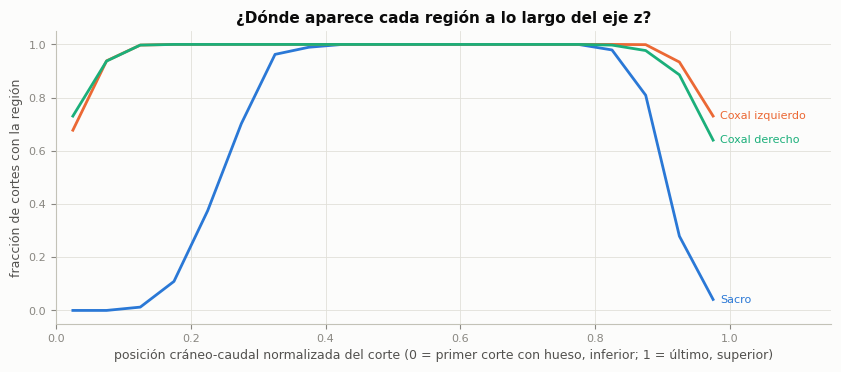

In [44]:
bins = np.linspace(0, 1, 21)
slices["zbin"] = pd.cut(slices.z_norm, bins, include_lowest=True, labels=(bins[:-1] + bins[1:]) / 2)
prof = slices.groupby("zbin", observed=False)[[f"has_{r}" for r in REG]].mean()
fig, ax = plt.subplots(figsize=(10, 3.8))
for r in REG:
    y = prof[f"has_{r}"].values
    x = prof.index.astype(float)
    ax.plot(x, y, color=C[r])
    ax.text(x[-1] + 0.01, y[-1], REG_NAME[r], color=C[r], fontsize=8, va="center")
ax.set_xlim(0, 1.15)
ax.set_xlabel("posición cráneo-caudal normalizada del corte (0 = primer corte con hueso, inferior; 1 = último, superior)")
ax.set_ylabel("fracción de cortes con la región")
ax.set_title("¿Dónde aparece cada región a lo largo del eje z?")
savefig(fig, "08_perfil_z")

,ancho mediano,alto mediano,lado menor < 4 px,< 8 px,< 16 px,< 32 px
región,,,,,,
Sacro,63.0,21.7,2.0 %,16.2 %,39.0 %,59.1 %
Coxal izquierdo,50.5,66.6,0.5 %,1.2 %,3.1 %,15.5 %
Coxal derecho,51.1,66.1,0.5 %,1.2 %,3.2 %,14.7 %


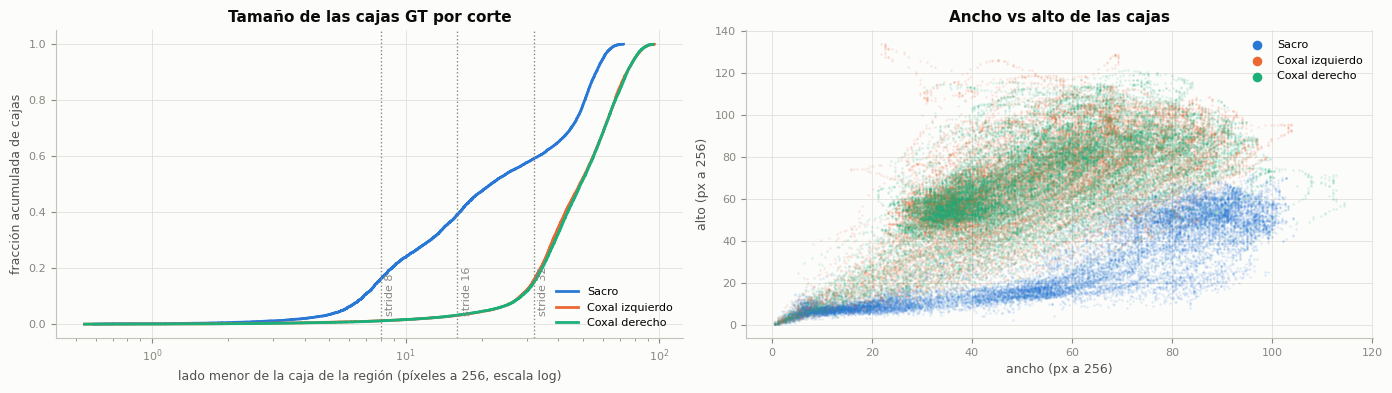

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ax = axes[0]
box_min = {}
for r in REG:
    s_ = slices[slices[f"has_{r}"]]
    v = np.minimum(s_[f"{r}_w_256b"], s_[f"{r}_h_256b"]).values
    box_min[r] = v
    ecdf(ax, v, C[r], label=REG_NAME[r])
for st in (8, 16, 32):
    ax.axvline(st, color=MUTED, ls=":", lw=1)
    ax.text(st * 1.04, 0.03, f"stride {st}", color=MUTED, fontsize=8, rotation=90, va="bottom")
ax.set_xscale("log")
ax.set_xlabel("lado menor de la caja de la región (píxeles a 256, escala log)")
ax.set_ylabel("fracción acumulada de cajas")
ax.set_title("Tamaño de las cajas GT por corte")
ax.legend(loc="lower right")

ax = axes[1]
for r in REG:
    s_ = slices[slices[f"has_{r}"]]
    ax.scatter(s_[f"{r}_w_256b"], s_[f"{r}_h_256b"], s=3, alpha=0.15, color=C[r], label=REG_NAME[r], rasterized=True)
ax.set_xlabel("ancho (px a 256)")
ax.set_ylabel("alto (px a 256)")
ax.set_title("Ancho vs alto de las cajas")
leg = ax.legend(markerscale=4)
for h in leg.legend_handles:
    h.set_alpha(1)
fig.tight_layout()
savefig(fig, "08_cajas")

rows = []
for r in REG:
    s_ = slices[slices[f"has_{r}"]]
    v = box_min[r]
    rows.append({"región": REG_NAME[r], "ancho mediano": s_[f"{r}_w_256b"].median(), "alto mediano": s_[f"{r}_h_256b"].median(),
                 "lado menor < 4 px": pct((v < 4).mean()), "< 8 px": pct((v < 8).mean()), "< 16 px": pct((v < 16).mean()),
                 "< 32 px": pct((v < 32).mean())})
pd.DataFrame(rows).set_index("región").round(1)

In [46]:
rows = []
for r in REG:
    s_ = slices[slices[f"has_{r}"]]
    rows.append({
        "región": REG_NAME[r],
        "cortes con ≥2 fragmentos de la región": pct((s_[f"{r}_n_frag"] >= 2).mean()),
        "máx. fragmentos en un corte": int(s_[f"{r}_n_frag"].max()),
        "cortes donde la región tiene >1 isla": pct((s_[f"{r}_n_islands"] > 1).mean()),
        "cortes donde UN fragmento tiene >1 isla": pct((s_[f"{r}_max_islands_per_frag"] > 1).mean()),
        "fragmento más pequeño del corte < 20 px": pct((s_[f"{r}_min_frag_area_256b"] < 20).mean()),
        "< 50 px": pct((s_[f"{r}_min_frag_area_256b"] < 50).mean()),
    })
print("Instancias en 2D (a 256 con recorte óseo)")
pd.DataFrame(rows).set_index("región")

Instancias en 2D (a 256 con recorte óseo)


,cortes con ≥2 fragmentos de la región,máx. fragmentos en un corte,cortes donde la región tiene >1 isla,cortes donde UN fragmento tiene >1 isla,fragmento más pequeño del corte < 20 px,< 50 px
región,,,,,,
Sacro,22.9 %,4,41.6 %,40.3 %,5.8 %,15.0 %
Coxal izquierdo,27.0 %,4,27.9 %,18.8 %,3.3 %,6.6 %
Coxal derecho,28.2 %,4,28.2 %,17.7 %,3.0 %,6.0 %


In [47]:
px_total = 256 * 256 * bone_slices
share = {REG_NAME[r]: slices[f"{r}_area_256b"].sum() / px_total for r in REG}
share["fondo"] = 1 - sum(share.values())
edge_share = slices.frac_edge_px_256b.sum() / slices.fg_px_256b.sum()
print("Balance de píxeles en cortes con hueso (entrada 256, recorte óseo):")
for k_, v in share.items():
    print(f"  {k_:16s} {pct(v)}")
print(f"\nPíxeles de borde de fractura (1 px, 4-vecindad) sobre el hueso: {pct(edge_share)}  -> 1 : {1 / edge_share:.0f}")
print(f"Cortes con al menos un píxel de borde de fractura: {pct((slices.frac_edge_px_256 > 0).mean())}")
ce_w = {k_: round(float(np.sqrt(share["fondo"] / v)), 1) for k_, v in share.items()}
print("Pesos de CE ∝ 1/sqrt(frecuencia), fondo = 1:", ce_w)
print(f"pos_weight equivalente para BCE del borde (1/sqrt): {np.sqrt((1 - edge_share) / edge_share):.0f}")

Balance de píxeles en cortes con hueso (entrada 256, recorte óseo):
  Sacro            0.8 %
  Coxal izquierdo  1.3 %
  Coxal derecho    1.3 %
  fondo            96.6 %

Píxeles de borde de fractura (1 px, 4-vecindad) sobre el hueso: 0.2 %  -> 1 : 446
Cortes con al menos un píxel de borde de fractura: 34.7 %
Pesos de CE ∝ 1/sqrt(frecuencia), fondo = 1: {'Sacro': 10.8, 'Coxal izquierdo': 8.7, 'Coxal derecho': 8.7, 'fondo': 1.0}
pos_weight equivalente para BCE del borde (1/sqrt): 21


> **Decisión 8 — Diseño de las cabezas 2D**
>
> **Clasificación**
> - Entre los cortes con hueso, el sacro aparece en 66 % y cada coxal en ~96 %. Sin cortes vacíos, los coxales casi no tienen negativos y el AUC queda mal condicionado.
> - Se entrena y **se evalúa sobre todos los cortes**, incluidos los vacíos (prevalencia 50 / 73 / 72 %). No hace falta `pos_weight`.
>
> **Detección**
> - Las cajas del sacro son finas: mediana 60 × 21 px; **40 % tiene el lado menor < 16 px y 18 % < 8 px**. Un grid de stride 16 perdería el sacro, así que se usa **stride 8** (como estaba planeado).
> - Las cajas GT con lado < 4 px (2,3 % del sacro) se marcan como "ignorar".
> - Los coxales (mediana 48 × 64 px) no presentan problema.
>
> **Instancias**
> - En 23–28 % de los cortes hay ≥ 2 fragmentos de la misma región.
> - En 18–40 % un solo fragmento aparece como varias islas. **Las componentes 2D no equivalen a instancias → componentes en 3D tras apilar** (confirmado).
>
> **Segmentación**
> - El primer plano es solo 3,2 % de los píxeles: CE + Dice, con pesos de CE ∝ 1/√frecuencia (≈ 11 / 9 / 9 frente a 1 del fondo).
> - El **borde de fractura es 1 de cada ~444 píxeles de hueso** y aparece en 35 % de los cortes. El objetivo se dilata a 2–3 px y se usa BCE con `pos_weight ≈ 21` + Dice.

## 9. Balance de la partición (`01_data/splits.json`)

La partición debe ser por paciente (sin fuga) y parecida en lo que importa: patrón de fracturas, número de fragmentos, fragmentos sin contacto, orientación, espesor de corte y cantidad de cortes.

In [48]:
sec_nc = sec.groupby("case_id").contacto.apply(lambda s: int((~s).sum()))
cases["sec_sin_contacto"] = cases.case_id.map(sec_nc).fillna(0).astype(int)
cases["n_secundarios"] = cases.case_id.map(sec.groupby("case_id").size()).fillna(0).astype(int)
bal = cases.groupby("split").agg(
    casos=("case_id", "size"),
    cortes_con_hueso=("slices_with_bone", "sum"),
    fragmentos_media=("total_fragments", "mean"),
    secundarios_total=("n_secundarios", "sum"),
    secundarios_sin_contacto=("sec_sin_contacto", "sum"),
    sacro_fracturado=("n_frag_SA", lambda s: pct((s > 1).mean())),
    coxal_izq_fracturado=("n_frag_LI", lambda s: pct((s > 1).mean())),
    coxal_der_fracturado=("n_frag_RI", lambda s: pct((s > 1).mean())),
    RAS=("orientation_orig", lambda s: pct((s == "RAS").mean())),
    dz_mediana=("dz", "median"),
).reindex(["train", "val", "test"])
bal.T

split,train,val,test
casos,70,15,15
cortes_con_hueso,16981,3569,3766
fragmentos_media,5.814,5.6,5.6
secundarios_total,197,39,39
secundarios_sin_contacto,22,4,5
sacro_fracturado,44.3 %,46.7 %,46.7 %
coxal_izq_fracturado,67.1 %,66.7 %,60.0 %
coxal_der_fracturado,65.7 %,60.0 %,60.0 %
RAS,35.7 %,33.3 %,26.7 %
dz_mediana,0.801,0.8,0.8


In [49]:
# Diferencia estandarizada de medias (SMD) entre cada split y el total: < 0,1 excelente, < 0,25 aceptable
bal_vars = pd.DataFrame({
    "sacro_fracturado": (cases.n_frag_SA > 1).astype(int), "coxal_izq_fracturado": (cases.n_frag_LI > 1).astype(int),
    "coxal_der_fracturado": (cases.n_frag_RI > 1).astype(int), "total_fragments": cases.total_fragments,
    "sec_sin_contacto": cases.sec_sin_contacto,
    "sec_pequenos": cases.case_id.map(sec[sec.volume_cm3 < 5].groupby("case_id").size()).fillna(0),
    "es_ras": (cases.orientation_orig == "RAS").astype(int), "dz_grueso": (cases.dz > 0.9).astype(int),
})
smd = ((bal_vars.groupby(cases.split).mean() - bal_vars.mean()).abs() / bal_vars.std(ddof=0)).T.reindex(columns=["train", "val", "test"])
print(f"SMD máximo de la partición actual: {smd.values.max():.3f}")
smd.round(3)

SMD máximo de la partición actual: 0.155


split,train,val,test
sacro_fracturado,0.014,0.034,0.034
coxal_izq_fracturado,0.024,0.014,0.127
coxal_der_fracturado,0.036,0.083,0.083
total_fragments,0.053,0.124,0.124
sec_sin_contacto,0.007,0.066,0.035
sec_pequenos,0.023,0.000,0.105
es_ras,0.036,0.014,0.155
dz_grueso,0.014,0.034,0.101


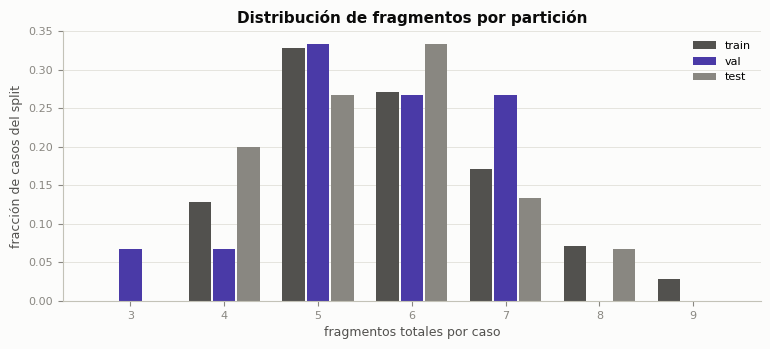

In [50]:
fig, ax = plt.subplots(figsize=(9, 3.5))
kk = sorted(cases.total_fragments.unique())
w = 0.26
for i, sp in enumerate(["train", "val", "test"]):
    vc = cases[cases.split == sp].total_fragments.value_counts(normalize=True).reindex(kk, fill_value=0)
    ax.bar(np.array(kk) + (i - 1) * w, vc.values, width=w - 0.02, color=[INK2, SEC_C, MUTED][i], label=sp)
ax.set_xticks(kk)
ax.set_xlabel("fragmentos totales por caso")
ax.set_ylabel("fracción de casos del split")
ax.set_title("Distribución de fragmentos por partición")
ax.legend()
ax.grid(axis="x", visible=False)
savefig(fig, "09_splits")

> **Decisión 9 — Partición regenerada (v2)**
> - La v1 estratificaba solo por "≤ 6 / > 6 fragmentos". Quedaba desbalanceada: SMD máximo **0,44**, con el test en 67 % de sacros fracturados frente a 43 % en train, y 47 % frente a 69 % de coxales izquierdos. Eso sesga todas las métricas finales.
> - `create_splits.py` ahora prueba 20 000 particiones aleatorias (semilla 42) y elige la de **menor SMD máximo** sobre: fractura por región, nº de fragmentos, secundarios sin contacto, secundarios pequeños, orientación y dz.
> - Resultado: **SMD máximo 0,155** (< 0,25, aceptable).
> - `splits.json` pasa a versión 2, con su `sha256` y el método. La v1 queda respaldada en `000_pruebas_y_experimentos_locales/`.
> - Las tablas de este notebook ya reflejan la v2.

## 10. Casos difíciles (lista de vigilancia)

Puntaje simple de dificultad esperada por caso, para contrastar después con la galería de los 5 peores casos: secundarios pequeños (< 5 cm³), secundarios sin contacto (medida de distancia no trivial), fragmentos del GT partidos en varias piezas, número de secundarios y fracción de cortes con varias islas.

In [51]:
small = sec[sec.volume_cm3 < 5].groupby("case_id").size()
split_gt = frags[frags.n_cc_ge_100mm3 > 1].groupby("case_id").size()
isl = slices.assign(multi=lambda d: (d[[f"{r}_n_islands" for r in REG]].fillna(0) > 1).any(axis=1)).groupby("case_id").multi.mean()
diff = cases.set_index("case_id")[["split", "patron", "n_secundarios", "sec_sin_contacto"]].copy()
diff["secundarios_<5cm3"] = small.reindex(diff.index).fillna(0).astype(int)
diff["fragmentos_GT_partidos"] = split_gt.reindex(diff.index).fillna(0).astype(int)
diff["cortes_multi_isla"] = isl.reindex(diff.index).round(2)
z = lambda s: (s - s.mean()) / (s.std() + 1e-9)
diff["puntaje"] = (z(diff.n_secundarios) + z(diff.sec_sin_contacto) + z(diff["secundarios_<5cm3"])
                   + z(diff.fragmentos_GT_partidos) + z(diff.cortes_multi_isla)).round(2)
diff.sort_values("puntaje", ascending=False).head(10)

,split,patron,n_secundarios,sec_sin_contacto,secundarios_<5cm3,fragmentos_GT_partidos,cortes_multi_isla,puntaje
case_id,,,,,,,,
084,test,Sacro + Coxal izquierdo + Coxal derecho,5,2,2,2,0.78,11.69
075,test,Sacro + Coxal izquierdo,4,2,2,1,0.75,8.82
039,train,Sacro + Coxal izquierdo + Coxal derecho,6,1,2,1,0.60,7.46
054,train,Coxal izquierdo + Coxal derecho,4,4,1,0,0.61,7.11
031,train,Sacro + Coxal izquierdo + Coxal derecho,5,1,1,2,0.62,7.02
024,train,Sacro + Coxal izquierdo + Coxal derecho,6,2,2,0,0.56,6.81
087,train,Sacro + Coxal izquierdo,5,1,2,0,0.79,6.77
052,val,Sacro + Coxal izquierdo + Coxal derecho,4,2,1,1,0.60,5.75
064,train,Sacro + Coxal derecho,4,0,0,2,0.82,5.10


> **Decisión 10 — Lista de vigilancia**
> - Los casos con mayor puntaje (084, 075, 039, 054, 031, 024, 087, 052, 064, 085) combinan muchos secundarios, fragmentos separados, piezas pequeñas y GT partido. Se suman:
>   - los de diastasis de sínfisis (015, 019, 022, 047, 063, 068, 072, 075, 088, 092);
>   - los de metal cercano (027, 100).
> - Cuando el modelo esté entrenado, la galería de los **5 peores casos** se contrasta con esta lista. Si coinciden, las hipótesis de falla quedan respaldadas por el EDA; si no, hay un modo de falla que el EDA no anticipó.

## 11. Inspección visual

Caso con más fragmentos secundarios: tres cortes axiales con la etiqueta superpuesta (color por macro-hueso, tono por fragmento; contorno negro = borde de fractura) y los dos recortes candidatos. Requiere los `.mha` en `01_data`.

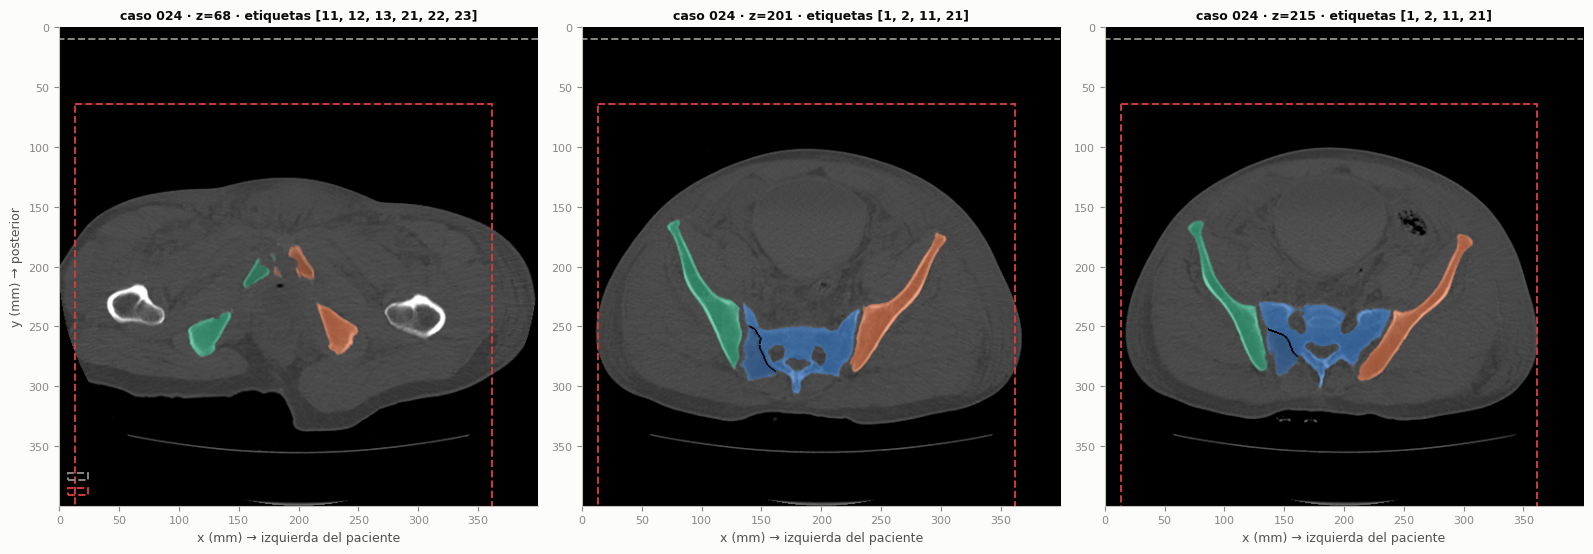

In [52]:
from matplotlib.colors import to_rgb
from scipy import ndimage as ndi

from pengwin.data.data_loader import apply_bone_window, get_dataset_pairs, load_and_standardize_mha
from pengwin.data.preprocessing import compute_body_crop, compute_bone_crop

DEMO = cases.sort_values(["n_secundarios", "sec_sin_contacto"], ascending=False).case_id.iloc[0]
pairs = {p["case_id"]: p for p in get_dataset_pairs(ROOT / "01_data")} if (ROOT / "01_data" / "PENGWIN_CT_train_labels").is_dir() else {}
if DEMO in pairs:
    img, sp, _ = load_and_standardize_mha(pairs[DEMO]["image_path"])
    lab, _, _ = load_and_standardize_mha(pairs[DEMO]["label_path"], is_label=True)
    body_c, bone_c = compute_body_crop(img, sp), compute_bone_crop(img, sp)
    s_demo = slices[slices.case_id == DEMO]
    z_many = int(s_demo.assign(nf=s_demo[[f"{r}_n_frag" for r in REG]].fillna(0).sum(axis=1)).nf.idxmax())
    z_edge = int(s_demo.frac_edge_px_256.idxmax())
    zs = [int(s_demo.loc[z_many, "z"]), int(s_demo.loc[z_edge, "z"]), int(s_demo.z.quantile(0.7))]

    def overlay(z):
        base = apply_bone_window(img[z])
        rgb = np.stack([base] * 3, -1)
        l2 = lab[z]
        for lbl in np.unique(l2[l2 > 0]):
            reg = REG[(lbl - 1) // 10]
            shade = 1 - 0.18 * ((lbl - 1) % 10)          # principal = tono pleno; secundarios más oscuros
            col = np.array(to_rgb(C[reg])) * shade
            m_ = l2 == lbl
            rgb[m_] = 0.45 * rgb[m_] + 0.55 * col
        edge = np.zeros_like(l2, bool)
        for ax_ in (0, 1):
            for sh in (1, -1):
                nb = np.roll(l2, sh, axis=ax_)
                edge |= (l2 > 0) & (nb > 0) & (l2 != nb)
        rgb[edge] = 0
        return rgb

    fig, axes = plt.subplots(1, 3, figsize=(16, 5.6))
    for ax, z in zip(axes, zs):
        ax.imshow(overlay(z), extent=(0, img.shape[2] * sp[2], img.shape[1] * sp[1], 0))
        for cr, col, name in ((body_c, MUTED, "recorte cuerpo"), (bone_c, REF, "recorte óseo")):
            ax.add_patch(plt.Rectangle((cr.x0 * sp[2], cr.y0 * sp[1]), cr.side_px * sp[2], cr.side_px * sp[1],
                                       fill=False, ec=col, lw=1.4, ls="--", label=name))
        present = sorted(int(v) for v in np.unique(lab[z]) if v)
        ax.set_title(f"caso {DEMO} · z={z} · etiquetas {present}", fontsize=9)
        ax.set_xlabel("x (mm) → izquierda del paciente")
        ax.grid(False)
    axes[0].set_ylabel("y (mm) → posterior")
    axes[0].legend(loc="lower left", fontsize=7)
    fig.tight_layout()
    savefig(fig, "11_cortes_ejemplo")
else:
    print("Volúmenes no disponibles: se omite la inspección visual.")

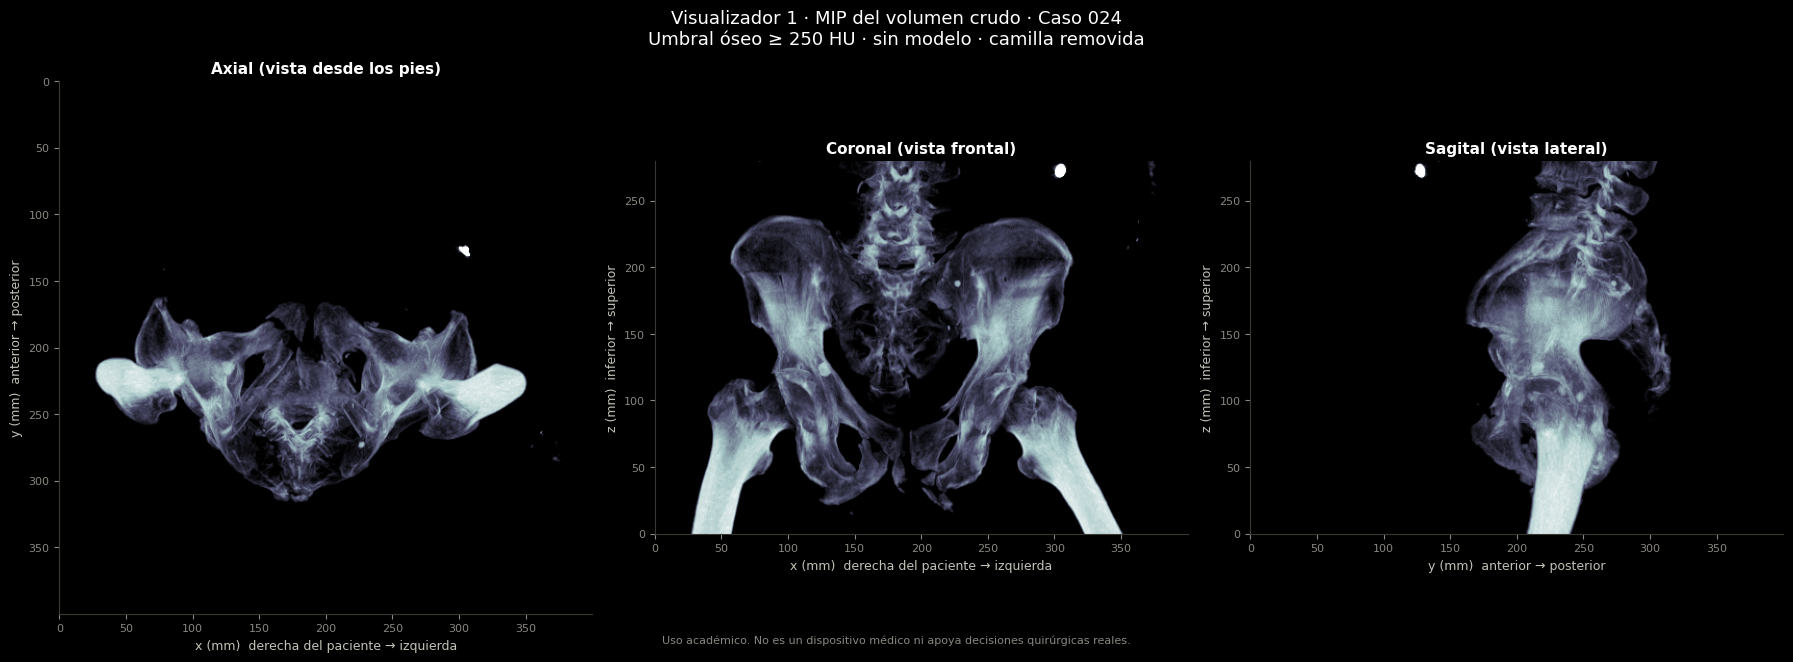

In [53]:
from pengwin.visualization.mip_viewer import plot_orthogonal_mip

if DEMO in pairs:
    fig = plot_orthogonal_mip(img, sp, DEMO, save_path=FIG / f"11_mip_{DEMO}.png")
    plt.show()

> **Decisión 11 — Validación visual**
> - Tras reorientar, el coxal izquierdo (naranja) queda a la derecha de la imagen: convención radiológica, x → izquierda del paciente.
> - El recorte óseo (rojo) es claramente más ajustado que el del cuerpo (gris) y no corta hueso.
> - Los bordes de fractura (contorno negro) son líneas de 1 píxel entre fragmentos del mismo color base, lo que confirma la necesidad de un objetivo de borde dilatado.
> - En el MIP, la camilla ya no aparece y el metal no satura la escala.

## 12. Resumen de decisiones

| # | Decisión | Evidencia (este notebook) | Dónde se implementa |
|---|---|---|---|
| 1 | Reorientar todo a LPS; imagen `float32`, etiqueta `uint8` | 34/100 casos RAS | `data_loader.py`, `test_orientation.py` |
| 2 | Recorte **óseo** por volumen → 256×256; spacing efectivo guardado por caso | 1,29 vs 1,56 mm/px; 100/100 sin cortar hueso | `preprocessing.compute_bone_crop`, caché de cortes |
| 3 | Entrada 2.5D con Δ = round(2 mm/dz) | Δ = 2 (78) / 3 (22) cortes | `dataset.py` |
| 4 | Ventana L400/W1800 y recorte de HU a [−1024, 3071] | 99,6 % del hueso sin saturar; relleno hasta −6211 | `apply_bone_window`, caché |
| 5 | MIP con umbral de 250 HU, camilla removida, escala fija | 43,6 % del hueso < 250 HU (solo visualización) | `mip_viewer.py` |
| 6 | No excluir casos por metal; nuevo criterio volumétrico | 0 casos con metal en la pelvis | auditoría |
| 7 | Detección con grid de **stride 8**; cajas < 4 px = ignorar | 40 % de cajas del sacro < 16 px | `heads.py` |
| 8 | Instancias por **componentes 3D** + reasignar < 0,1 cm³ | islas 2D en 18–40 % de cortes; 33 fragmentos GT partidos | `postprocess/instances.py` |
| 9 | Salida de **borde de fractura** dilatada, BCE (`pos_weight` ≈ 21) + Dice | 88,7 % de secundarios en contacto; borde 1:444 | `heads.py`, `losses.py` |
| 10 | CE + Dice con pesos ∝ 1/√frecuencia | primer plano 3,2 % | `losses.py` |
| 11 | Clasificación entrenada/evaluada con cortes vacíos | coxales en 96 % de cortes con hueso | `dataset.py`, evaluación |
| 12 | Distancia: "en contacto" si d ≤ diagonal del vóxel; error pred-GT por grupo | 244/275 en contacto | `measurement/separation.py`, dashboard |
| 13 | Dice por fragmento estratificado por volumen | 14,5 % de secundarios < 5 cm³ | `evaluation/seg_metrics.py` |
| 14 | Partición v2 balanceada (SMD máx 0,155 vs 0,44) | §9 | `create_splits.py`, `splits.json` |
| 15 | Lista de vigilancia para el análisis de errores | §10 | informe / model card |